[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/sec-filing-text-nlp-python.ipynb)

# SEC EDGAR Filing Text Extraction for NLP with Python -- Free, No API Key

Use **edgartools** to extract clean text from SEC filings for NLP and AI analysis -- completely free, no API key or paid subscription required. Get full filing text, individual sections, or structured chunks ready for machine learning pipelines and LLM context windows.

**What you'll learn:**
- Extract full filing text as plain text, markdown, or HTML
- Pull specific sections (business, risk factors, MD&A) by item number
- Get word and character counts for each section
- Search within filings for specific terms
- Access structured chunks for LLM context windows
- Compare text volumes across companies

## Install edgartools

In [1]:
!pip install -U edgartools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 148.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.0/134.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 21.3 MB/s eta 0:00:00


## Setup

The SEC requires all automated tools to identify themselves. Replace the email below with your own -- any valid email works.

In [2]:
import pandas as pd
from edgar import *

# The SEC requires you to identify yourself (any email works)
set_identity("your.name@example.com")

## Extract Filing Text in 3 Lines

Every SEC filing can be converted to plain text, markdown, or HTML. edgartools handles all the parsing automatically:

In [3]:
filing = Company("NVDA").get_filings(form="10-K")[0]

text = filing.text()
markdown = filing.markdown()
html = filing.html()

print(f"Plain text: {len(text):>10,} chars  ({len(text.split()):,} words)")
print(f"Markdown:   {len(markdown):>10,} chars")
print(f"HTML:       {len(html):>10,} chars")
print(f"\nFirst 500 chars of text:\n")
print(text[:500])

Plain text:    410,537 chars  (49,112 words)
Markdown:      429,312 chars
HTML:        1,967,816 chars

First 500 chars of text:

Table of Contents

UNITED STATES

SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

____________________________________________________________________________________________

FORM 10-K

  ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934  
 ────────────────────────────────────────────────────────────────────────────────────────

For the fiscal year ended January 25, 2026

OR

  TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXC


## Extract Specific Sections by Item Number

For NLP, you often need specific sections rather than the full filing. Parse a 10-K and access any section by item number:

In [4]:
tenk = filing.obj()

# Key sections for NLP analysis
business = tenk["1"]        # Item 1: Business description
risks = tenk["1A"]          # Item 1A: Risk factors
mda = tenk["7"]             # Item 7: Management Discussion & Analysis

print(f"{'Section':<20s} {'Words':>10s} {'Characters':>12s}")
print(f"{'-'*20} {'-'*10} {'-'*12}")
for name, text in [("Business", business), ("Risk Factors", risks), ("MD&A", mda)]:
    print(f"{name:<20s} {len(text.split()):>10,} {len(text):>12,}")

print(f"\nBusiness description (first 500 chars):\n")
print(business[:500])

Section                   Words   Characters
-------------------- ---------- ------------
Business                  7,028       48,222
Risk Factors             17,065      114,773
MD&A                      5,108       34,156

Business description (first 500 chars):

Item 1. Business

Our Company

NVIDIA pioneered accelerated computing to help solve the most challenging computational problems. NVIDIA is now a data center scale AI infrastructure company reshaping all industries.

Our technology stack includes the foundational NVIDIA CUDA development platform that runs on all NVIDIA GPUs, as well as hundreds of domain-specific software libraries, frameworks, algorithms, software development kits, or SDKs, and application programming interfaces, or APIs. This d


In [10]:
import pandas as pd
import edgar

# Ensure identity is set (it was set in a previous cell, but good practice for standalone execution)
edgar.set_identity("your.name@example.com")

print("Fetching list of all companies from SEC database... This may take a moment.")
all_companies = edgar.get_companies()
print(f"Found {len(all_companies)} companies in total.")

# Define common SIC code ranges for technology companies
# This list is a representative subset and can be expanded for a more exhaustive definition.
tech_sic_ranges = [
    (3570, 3579), # Computer and Office Equipment
    (3660, 3679), # Communications Equipment, Electronic Components
    (4812, 4813), # Radiotelephone and Telephone Communications (e.g., telcos, wireless)
    (7370, 7379), # Computer Programming, Data Processing, and Other Computer Related Services
    (5045, 5045), # Computers and Computer Peripheral Equipment and Software (Wholesale)
]

# Filter companies by SIC code
if 'SIC' in all_companies.columns:
    all_companies['SIC_numeric'] = pd.to_numeric(all_companies['SIC'], errors='coerce')
    all_companies_filtered_sic = all_companies.dropna(subset=['SIC_numeric'])

    tech_companies_by_sic = pd.DataFrame()
    for start, end in tech_sic_ranges:
        tech_companies_by_sic = pd.concat([
            tech_companies_by_sic,
            all_companies_filtered_sic[
                (all_companies_filtered_sic['SIC_numeric'] >= start) &
                (all_companies_filtered_sic['SIC_numeric'] <= end)
            ]
        ])

    # Remove duplicates in case a company's SIC falls into multiple defined ranges
    tech_companies_by_sic = tech_companies_by_sic.drop_duplicates(subset=['CIK'])
    print(f"Found {len(tech_companies_by_sic)} companies matching technology SIC codes.")

    # Filter for US companies based on common US stock exchanges
    us_exchanges = ['NYSE', 'NASDAQ', 'AMEX', 'OTC'] # Common US exchanges
    tech_companies_us = tech_companies_by_sic[tech_companies_by_sic['Exchange'].isin(us_exchanges)]
    print(f"Found {len(tech_companies_us)} US-based technology companies.")

    # Get the tickers of the first 1000 tech companies, remove any potential NaN values, and convert to a list
    first_1000_tech_tickers = tech_companies_us['Ticker'].head(1000).dropna().tolist()

    print(f"First {len(first_1000_tech_tickers)} US tech tickers:")
    print(first_1000_tech_tickers)
else:
    print("The 'SIC' column was not found in the companies list. Cannot filter by tech industry.")

# You can use this list `first_1000_tech_tickers` in subsequent cells.

Fetching list of all companies from SEC database... This may take a moment.


AttributeError: module 'edgar' has no attribute 'get_companies'

In [3]:
"""
Get the first 1000 US tech company tickers.

Two methods:
  - Method 1 (recommended): NASDAQ screener API — no key needed, works in most environments
  - Method 2 (fallback):    yfinance sector filtering — slower but very accurate
"""

import requests
import pandas as pd


# ─────────────────────────────────────────────
# METHOD 1 — NASDAQ Screener API (fastest)
# ─────────────────────────────────────────────
def get_tech_tickers_nasdaq(limit: int = 1000) -> list[str]:
    """
    Pulls US Technology-sector tickers directly from the NASDAQ stock screener.
    No API key required.
    """
    url = "https://api.nasdaq.com/api/screener/stocks"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept-Language": "en-US,en;q=0.9",
        "Origin": "https://www.nasdaq.com",
        "Referer": "https://www.nasdaq.com/",
    }
    params = {
        "tableonly": "true",
        "limit": limit,
        "offset": 0,
        "sector": "Technology",
        "download": "true",
    }

    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()

    rows = response.json()["data"]["rows"]
    tickers = [row["symbol"] for row in rows][:limit]
    return tickers


# ─────────────────────────────────────────────
# METHOD 2 — yfinance sector filter (accurate, slower)
# ─────────────────────────────────────────────
def get_tech_tickers_yfinance(limit: int = 1000) -> list[str]:
    """
    Downloads all US tickers from a public GitHub list, then filters to
    Technology sector using yfinance. Slow (~1-2 min for 1000 results).
    Run: pip install yfinance requests
    """
    import yfinance as yf
    import time

    # Public list of all US-listed tickers
    url = "https://raw.githubusercontent.com/rreichel3/US-Stock-Symbols/main/all/all_tickers.txt"
    r = requests.get(url, timeout=30)
    all_tickers = r.text.strip().split("\n")

    tech_tickers = []
    for ticker in all_tickers:
        if len(tech_tickers) >= limit:
            break
        try:
            info = yf.Ticker(ticker).info
            if info.get("sector") == "Technology" and info.get("country") == "United States":
                tech_tickers.append(ticker)
                print(f"  [{len(tech_tickers)}] {ticker}")
        except Exception:
            pass
        time.sleep(0.05)  # polite rate limiting

    return tech_tickers


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("Fetching 1000 US tech tickers via NASDAQ screener...")
    try:
        tickers = get_tech_tickers_nasdaq(1000)
        method = "NASDAQ screener"
    except Exception as e:
        print(f"NASDAQ screener failed ({e}), falling back to yfinance...")
        tickers = get_tech_tickers_yfinance(1000)
        method = "yfinance"

    print(f"\n✅ Got {len(tickers)} tickers via {method}")
    print("First 20:", tickers[:20])

    # Save to CSV
    pd.DataFrame({"ticker": tickers}).to_csv("tech_tickers.csv", index=False)
    print(f"\nSaved to tech_tickers.csv")

    # The list itself
    print("\ntickers =", tickers)


Fetching 1000 US tech tickers via NASDAQ screener...

✅ Got 774 tickers via NASDAQ screener
First 20: ['AAOI', 'AAPL', 'ABTC', 'ABTS', 'ACIW', 'ACLS', 'ACMR', 'ADBE', 'ADEA', 'ADI', 'ADSK', 'AEIS', 'AEYE', 'AGMH', 'AGYS', 'AI', 'AIAI', 'AIFF', 'AIMD', 'AIMDW']

Saved to tech_tickers.csv

tickers = ['AAOI', 'AAPL', 'ABTC', 'ABTS', 'ACIW', 'ACLS', 'ACMR', 'ADBE', 'ADEA', 'ADI', 'ADSK', 'AEIS', 'AEYE', 'AGMH', 'AGYS', 'AI', 'AIAI', 'AIFF', 'AIMD', 'AIMDW', 'AIP', 'AIRG', 'AISP', 'AISPW', 'AIXI', 'ALAB', 'ALAR', 'ALGM', 'ALKT', 'ALMU', 'ALOT', 'ALOY', 'ALRM', 'AMAT', 'AMBA', 'AMBQ', 'AMD', 'AMKR', 'AMPL', 'AMST', 'AOSL', 'APH', 'API', 'APP', 'APPF', 'APPN', 'APXT', 'ARBB', 'ARBE', 'ARBEW', 'AREN', 'ARM', 'ARQQ', 'ARQQW', 'ARW', 'ASAN', 'ASML', 'ASST', 'ASTI', 'ASUR', 'ASX', 'ASYS', 'ATGL', 'ATHM', 'ATHR', 'ATOM', 'AUID', 'AUR', 'AUROW', 'AUUD', 'AVGO', 'AVNW', 'AVPT', 'AVT', 'AWRE', 'AXTI', 'AZTA', 'BAND', 'BB', 'BBAI', 'BEEM', 'BHE', 'BIDU', 'BILI', 'BILL', 'BKSY', 'BKTI', 'BL', 'BLIN', '

In [5]:
# 2. Lista de empresas tecnológicas
import re
#from tqdm import tqdm
from tqdm.notebook import tqdm



def natural_sort_key(item):
    """
    Generates a key for natural sorting of item strings like 'Item 1', 'Item 1A'.
    It splits the string into a list of number and non-number chunks.
    """
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', item)]

tech_list = ['AAPL','MSFT','NVDA', 'GOOGL', 'AMZN','META']
tech_tickers = tickers
tech_list_final = []

# crear un nuevo listado para meter solo aquellas empresas de las que hay referentes

for i in tqdm(tech_tickers):
    print('*'*40)
    print(f"Processing: {i}")

    # Fetch filings for the ticker
    filings = Company(i).get_filings(form="10-K")

    # Check if any filings were found before accessing index [0]
    if len(filings) > 0:
        tech_list_final.append(i)
        filing = filings[0]
        tenk = filing.obj()
        print(f"Found 10-K filed on: {tenk.filing_date}")

        for item in tenk.items:
            text = tenk[item]
            try:
                words = len(text.split())
            except AttributeError:
                print(f"¡Alerta! El elemento '{item}' no contiene texto (es None).")
                words = 0
        '''
        for item in tenk.items:
            text = tenk[item]
            words = len(text.split())
            # print(f"{item:12s} {words:>8,} words")
        '''
    else:
        print(f"No 10-K filings found for {i}. Skipping...")

  0%|          | 0/774 [00:00<?, ?it/s]

****************************************
Processing: AAOI
Found 10-K filed on: 2026-02-26
****************************************
Processing: AAPL
Found 10-K filed on: 2025-10-31
****************************************
Processing: ABTC
Found 10-K filed on: 2026-03-27
****************************************
Processing: ABTS
No 10-K filings found for ABTS. Skipping...
****************************************
Processing: ACIW
Found 10-K filed on: 2026-02-26
****************************************
Processing: ACLS
Found 10-K filed on: 2026-02-26
****************************************
Processing: ACMR
Found 10-K filed on: 2026-03-02
****************************************
Processing: ADBE
Found 10-K filed on: 2026-01-15
****************************************
Processing: ADEA
Found 10-K filed on: 2026-02-26
****************************************
Processing: ADI
Found 10-K filed on: 2025-11-25
****************************************
Processing: ADSK
Found 10-K filed on: 2026-03-03

****************************************
Processing: AI
Found 10-K filed on: 2025-06-23
****************************************
Processing: AIAI
No 10-K filings found for AIAI. Skipping...
****************************************
Processing: AIFF
Found 10-K filed on: 2026-03-31
****************************************
Processing: AIMD
Found 10-K filed on: 2026-03-30
****************************************
Processing: AIMDW
Found 10-K filed on: 2026-03-30
****************************************
Processing: AIP
Found 10-K filed on: 2026-02-12
****************************************
Processing: AIRG
Found 10-K filed on: 2026-02-26
****************************************
Processing: AISP
Found 10-K filed on: 2026-02-17
****************************************
Processing: AISPW
Found 10-K filed on: 2026-02-17
****************************************
Processing: AIXI
No 10-K filings found for AIXI. Skipping...
****************************************
Processing: ALAB
Found 10-K filed on

****************************************
Processing: CRNC
Found 10-K filed on: 2025-11-20
****************************************
Processing: CRNT
No 10-K filings found for CRNT. Skipping...
****************************************
Processing: CRSR
Found 10-K filed on: 2026-02-25
****************************************
Processing: CRUS
Found 10-K filed on: 2026-05-21
****************************************
Processing: CRWD
Found 10-K filed on: 2026-03-05
****************************************
Processing: CRWV
Found 10-K filed on: 2026-03-02
****************************************
Processing: CSAI
Found 10-K filed on: 2026-03-31
****************************************
Processing: CSIQ
No 10-K filings found for CSIQ. Skipping...
****************************************
Processing: CSPI
Found 10-K filed on: 2025-12-16
****************************************
Processing: CTS
Found 10-K filed on: 2026-02-24
****************************************
Processing: CTSH
Found 10-K filed on

****************************************
Processing: DOCN
Found 10-K filed on: 2026-02-24
****************************************
Processing: DOCS
Found 10-K filed on: 2026-05-19
****************************************
Processing: DOCU
Found 10-K filed on: 2026-03-18
****************************************
Processing: DOMO
Found 10-K filed on: 2026-04-16
****************************************
Processing: DOX
No 10-K filings found for DOX. Skipping...
****************************************
Processing: DOYU
No 10-K filings found for DOYU. Skipping...
****************************************
Processing: DQ
No 10-K filings found for DQ. Skipping...
****************************************
Processing: DSGX
No 10-K filings found for DSGX. Skipping...
****************************************
Processing: DSP
Found 10-K filed on: 2026-03-11
****************************************
Processing: DT
Found 10-K filed on: 2026-05-20
****************************************
Processing: DTCX
Fou

...

****************************************
Processing: RPGL
No 10-K filings found for RPGL. Skipping...
****************************************
Processing: RSSS
Found 10-K filed on: 2025-09-19
****************************************
Processing: RUM
Found 10-K filed on: 2026-03-05
****************************************
Processing: RUMBW
Found 10-K filed on: 2026-03-05
****************************************
Processing: RXT
Found 10-K filed on: 2026-03-06
****************************************
Processing: RYET
No 10-K filings found for RYET. Skipping...
****************************************
Processing: RZLV
No 10-K filings found for RZLV. Skipping...
****************************************
Processing: RZLVW
No 10-K filings found for RZLVW. Skipping...
****************************************
Processing: S
Found 10-K filed on: 2026-03-19


****************************************
Processing: SABR
Found 10-K filed on: 2026-02-18
****************************************
Processing: SAGT
No 10-K filings found for SAGT. Skipping...
****************************************
Processing: SAIC
Found 10-K filed on: 2026-03-16
****************************************
Processing: SAIH
Found 10-K filed on: 2022-02-18
****************************************
Processing: SAIHW
Found 10-K filed on: 2022-02-18
****************************************
Processing: SAIL
Found 10-K filed on: 2026-03-19
****************************************
Processing: SANG
No 10-K filings found for SANG. Skipping...
****************************************
Processing: SANM
Found 10-K filed on: 2025-11-13
****************************************
Processing: SAP
No 10-K filings found for SAP. Skipping...
****************************************
Processing: SATL
Found 10-K filed on: 2026-03-19
****************************************
Processing: SATLW
Found 

****************************************
Processing: SELX
No 10-K filings found for SELX. Skipping...
****************************************
Processing: SHAZ
Found 10-K filed on: 2026-03-31
****************************************
Processing: SHLS
Found 10-K filed on: 2026-02-24
****************************************
Processing: SHMD
No 10-K filings found for SHMD. Skipping...
****************************************
Processing: SHMDW
No 10-K filings found for SHMDW. Skipping...
****************************************
Processing: SHOP
Found 10-K filed on: 2026-04-29
****************************************
Processing: SIFY
No 10-K filings found for SIFY. Skipping...
****************************************
Processing: SIMO
No 10-K filings found for SIMO. Skipping...
****************************************
Processing: SITM
Found 10-K filed on: 2026-02-11
****************************************
Processing: SJ
Found 10-K filed on: 2020-03-20
****************************************

****************************************
Processing: SWMR
No 10-K filings found for SWMR. Skipping...
****************************************
Processing: SY
No 10-K filings found for SY. Skipping...
****************************************
Processing: SYNA
Found 10-K filed on: 2025-08-21
****************************************
Processing: TACT
Found 10-K filed on: 2026-03-12
****************************************
Processing: TAOP
No 10-K filings found for TAOP. Skipping...
****************************************
Processing: TASK
Found 10-K filed on: 2026-03-05
****************************************
Processing: TBLA
Found 10-K filed on: 2026-02-25
****************************************
Processing: TBLAW
Found 10-K filed on: 2026-02-25
****************************************
Processing: TBRG
Found 10-K filed on: 2026-04-30
****************************************
Processing: TCX
Found 10-K filed on: 2026-03-12
****************************************
Processing: TDC
Found 10-K 

****************************************
Processing: XYZ
Found 10-K filed on: 2026-02-26
****************************************
Processing: YAAS
No 10-K filings found for YAAS. Skipping...
****************************************
Processing: YALA
No 10-K filings found for YALA. Skipping...
****************************************
Processing: YEXT
Found 10-K filed on: 2026-03-10
****************************************
Processing: YMM
No 10-K filings found for YMM. Skipping...
****************************************
Processing: YMT
No 10-K filings found for YMT. Skipping...
****************************************
Processing: YOU
Found 10-K filed on: 2026-02-25
****************************************
Processing: YXT
No 10-K filings found for YXT. Skipping...
****************************************
Processing: ZDGE
Found 10-K filed on: 2025-10-28
****************************************
Processing: ZENA
No 10-K filings found for ZENA. Skipping...
************************************

In [6]:
print(len(tech_list_final))

572


In [7]:
import pickle

mi_lista = tech_list_final

with open('datos_lista.pkl', 'wb') as archivo:
    pickle.dump(mi_lista, archivo)

print("Lista guardada correctamente.")


Lista guardada correctamente.


In [ ]:
import pickle

with open('datos_lista.pkl', 'rb') as archivo:
    lista_recuperada = pickle.load(archivo)

print(lista_recuperada)


### Comparing Word Counts for Key 10-K Items Across Companies

To visualize the comparative disclosure for important sections, we'll collect the word counts for 'Item 1' (Business), 'Item 1A' (Risk Factors), and 'Item 7' (Management's Discussion & Analysis) for each of the `tech_tickers`.

In [8]:
import pandas as pd
from IPython.display import display

# Initialize a list to store data for plotting
plot_data = []

# Define the key items we want to compare
#key_items_to_plot = ['Item 1', 'Item 1A', 'Item 7']
key_items_to_plot = sorted(tenk.items, key=natural_sort_key)


# Loop through each technology ticker
# for ticker_symbol in tech_tickers:
for ticker_symbol in tqdm(tech_list_final):
    print(f"Processing {ticker_symbol}...")
    try:
        # Get the latest 10-K filing for the company
        filing = Company(ticker_symbol).get_filings(form="10-K")[0]
        tenk = filing.obj()

        # Prepare a dictionary to hold the word counts for this ticker
        ticker_item_counts = {'Ticker': ticker_symbol}

        # Collect word counts for the key items
        for item_name in key_items_to_plot:
            if item_name in tenk.items:
                text = tenk[item_name]
                words = len(text.split())
                ticker_item_counts[item_name] = words
            else:
                # Handle cases where an item might not be present (e.g., if a 10-K structure differs)
                ticker_item_counts[item_name] = 0 # Or numpy.nan if you prefer

        plot_data.append(ticker_item_counts)

    except Exception as e:
        print(f"Could not process {ticker_symbol}: {e}")

# Convert the collected data into a pandas DataFrame
df_item_comparison = pd.DataFrame(plot_data)

display(df_item_comparison)

  0%|          | 0/572 [00:00<?, ?it/s]

Processing AAOI...
Processing AAPL...
Processing ABTC...
Processing ACIW...
Processing ACLS...
Processing ACMR...
Processing ADBE...
Processing ADEA...
Processing ADI...
Processing ADSK...
Processing AEIS...
Processing AEYE...
Processing AGYS...
Processing AI...
Processing AIFF...
Processing AIMD...
Processing AIMDW...
Processing AIP...
Processing AIRG...
Processing AISP...
Processing AISPW...
Processing ALAB...
Processing ALGM...
Processing ALKT...
Processing ALMU...
Processing ALOT...
Processing ALOY...
Processing ALRM...
Processing AMAT...
Processing AMBA...
Processing AMBQ...
Processing AMD...
Processing AMKR...
Processing AMPL...
Processing AMST...
Processing AOSL...
Processing APH...
Processing APP...
Processing APPF...
Processing APPN...
Processing APXT...
Processing AREN...
Processing ARW...
Processing ASAN...
Processing ASST...
Processing ASTI...
Processing ASUR...
Processing ASYS...
Processing ATHR...
Processing ATOM...
Processing AUID...
Processing AUR...
Processing AUROW...

Processing DOCN...
Processing DOCS...
Processing DOCU...
Processing DOMO...
Processing DSP...
Processing DT...
Processing DTCX...
Processing DTSS...
Processing DTST...
Processing DUOL...


Processing DUOT...
Processing DV...
Processing DVLT...
Processing DXC...
Processing EGAN...
Processing EMR...
Processing ENPH...
Processing ENS...
Processing EPAC...
Processing EPAM...
Processing ERII...
Processing ESP...


Processing ESTC...
Processing ETN...
Processing EVCM...
Processing EVER...
Processing EVGO...
Processing EVGOW...
Processing EVLV...
Processing EVLVW...
Processing EVTC...
Processing EXFY...
Processing FA...
Processing FATN...
Processing FDS...
Processing FIG...
Processing FIVN...
Processing FLEX...
Processing FLUT...
Processing FNGR...


...

Processing SABR...
Processing SAIC...
Processing SAIH...
Processing SAIHW...
Processing SAIL...
Processing SANM...
Processing SATL...
Processing SATLW...
Processing SBET...
Processing SCKT...
Processing SCSC...
Processing SEDG...
Processing SEGG...


Processing SHAZ...
Processing SHLS...
Processing SHOP...
Processing SITM...
Processing SJ...
Processing SKIL...
Processing SKLZ...
Processing SKYT...
Processing SLAB...
Processing SLNH...
Processing SLNHP...
Processing SLP...
Processing SMCI...
Processing SMRT...
Processing SMSI...
Processing SMTC...
Processing SMTK...
Processing SNAL...
Processing SNAP...
Processing SNDK...
Processing SNOW...
Processing SNPS...
Processing SNX...
Processing SOTK...
Processing SOUN...
Processing SOUNW...
Processing SPSC...
Processing SPT...
Processing SPWR...
Processing SPWRW...
Processing SSNC...
Processing SST...
Processing SSTI...
Processing SSTK...
Processing STRC...
Processing STRD...
Processing STRF...
Processing STRK...
Processing STX...
Processing SVCO...
Processing SWKS...


Processing SYNA...
Processing TACT...
Processing TASK...
Processing TBLA...
Processing TBLAW...
Processing TBRG...
Processing TCX...
Processing TDC...
Processing TEAD...
Processing TEAM...
Processing TEL...
Processing TEM...
Processing TENB...
Processing TLS...
Processing TOST...
Processing TRAK...
Processing TRIP...
Processing TRNR...
Processing TRT...
Processing TTAN...
Processing TTD...
Processing TTMI...
Processing TWAV...
Processing TWLO...
Processing TXN...
Processing TYGO...
Processing TYL...
Processing U...
Processing UCTT...
Processing UI...
Processing UIS...
Processing UMAC...
Processing UPLD...
Processing UPWK...
Processing UUU...
Processing VECO...
Processing VEEV...
Processing VELO...
Processing VERI...
Processing VERX...
Processing VHUB...
Processing VIA...
Processing VIAV...
Processing VICR...
Processing VISN...
Processing VPG...
Processing VREX...
Processing VRME...
Processing VRNS...
Processing VRSN...
Processing VRT...
Processing VS...
Processing VSAT...
Processing VS

Processing XYZ...
Processing YEXT...
Processing YOU...
Processing ZDGE...
Processing ZETA...
Processing ZIP...
Processing ZM...
Processing ZS...


,Ticker,Item 1,Item 1A,Item 1B,Item 1C,Item 2,Item 3,Item 4,Item 5,Item 6,...,Item 9,Item 9A,Item 9B,Item 9C,Item 10,Item 11,Item 12,Item 13,Item 15,Item 16
0,AAOI,8025,13613,6,684,88,42,9,391,3,...,14,1452,147,12,259,42,52,48,78,18559
1,AAPL,2325,9782,6,370,83,830,440,404,11,...,14,649,83,352,60,284,34,30,1761,316
2,ABTC,3714,21243,5,692,159,151,9,278,5,...,13,550,47,13,219,44,54,50,773,158
3,ACIW,5374,12531,894,0,139,37,9,779,3,...,14,904,279,0,109,38,54,59,17949,0
4,ACLS,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,ZDGE,5428,25953,6,1345,211,60,9,518,5,...,14,467,5,14,386,46,56,52,632,18930
568,ZETA,4639,21274,6,835,31594,815,10,559,3,...,14,1516,5,13,274,44,54,50,927,195
569,ZIP,3525,22645,7,1111,72,53,9,610,3,...,14,629,310,13,162,68,79,68,778,290
570,ZM,5986,31984,6,731,51,50,9,640,5,...,14,561,159,13,132,42,52,48,1108,387


Para analizar y visualizar la variabilidad del conteo de palabras de los ítems del 10-K a partir de tu DataFrame `df_item_comparison`, hay que tener en cuenta un factor clave: **el volumen de texto de las secciones difiere enormemente entre sí** (por ejemplo, el *Item 7* suele ser muchísimo más largo que el *Item 1A*).

Por lo tanto, no se puede usar métricas absolutas aisladas (como solo la desviación estándar) porque las secciones más largas siempre parecerán tener "más variabilidad" de forma engañosa.


---

### 0. Una corrección crítica antes de calcular: Ceros vs. `NaN`

En el código actual, si un ítem no existe, se le asigna un `0`. Introducir ceros en conteos de palabras sesgará por completo las medidas de variabilidad (bajará artificialmente la media y aumentará falsamente la desviación estándar). Lo correcto para el análisis estadístico es usar valores nulos (`np.nan`), de modo que Pandas los ignore legítimamente al calcular las dispersiones.

En el código de abajo incluyo esta conversión automática.

---

### 1. Las Medidas Estadísticas Clave

Para medir la variabilidad de datos de texto (que suelen ser asimétricos), se debe calcular:

* **Mediana ($Q_2$):** El centro real de los datos sin verse afectado por empresas que escriben reportes masivos.
* **Desviación Estándar ($\sigma$):** La medida de dispersión clásica.
* **Rango Intercuartílico ($IQR = Q_3 - Q_1$):** Mide el ancho del 50% central de las empresas. Es una medida de variabilidad muy robusta frente a valores extremos (outliers).
* **Coeficiente de Variación ($CV = \frac{\sigma}{\mu}$):** **Esta es la métrica más importante para ti**. Divide la desviación estándar entre la media ($\mu$). Al ser un porcentaje/proporción adimensional, te permite comparar directamente la variabilidad de un ítem corto con uno largo.

---

### 2. Código en Python: Tabla de Métricas y Gráficas de Variabilidad



```python
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREPARACIÓN DE DATOS Y MÉTRICAS
# ==========================================

# Identificar las columnas de los ítems (todas menos 'Ticker')
item_columns = [col for col in df_item_comparison.columns if col != 'Ticker']

# Clonamos el dataframe y reemplazamos los 0 por NaN para no adulterar la variabilidad
df_stats = df_item_comparison.copy()
df_stats[item_columns] = df_stats[item_columns].replace(0, np.nan)

# Calculamos los estadísticos básicos transpuestos (.T)
summary_table = df_stats[item_columns].describe().T

# Añadimos el Rango Intercuartílico (IQR) y el Coeficiente de Variación (CV)
summary_table['IQR'] = summary_table['75%'] - summary_table['25%']
summary_table['CV'] = summary_table['std'] / summary_table['mean']

# Renombramos columnas para mayor claridad en español
summary_table = summary_table.rename(columns={
    'mean': 'Media',
    '50%': 'Mediana',
    'std': 'Desv. Estándar',
    'min': 'Mínimo',
    'max': 'Máximo'
})

print("=== TABLA RESUMEN DE VARIABILIDAD POR ÍTEM ===")
display(summary_table[['Media', 'Mediana', 'Desv. Estándar', 'IQR', 'CV', 'Mínimo', 'Máximo']])


# ==========================================
# 2. VISUALIZACIÓN GRÁFICA
# ==========================================

# Configuración estética general
sns.set_theme(style="whitegrid")

# --- GRÁFICA A: Boxplot (Diagrama de Caja y Bigotes) ---
# Transformamos a formato "largo" (melt) requerido por Seaborn para comparar variables
df_long = df_stats.melt(id_vars=['Ticker'], value_vars=item_columns, var_name='Item', value_name='Palabras')
df_long = df_long.dropna() # eliminamos nulos para graficar

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_long, x='Item', y='Palabras', palette='Set2', hue='Item', legend=False)
plt.yscale('log') # CRÍTICO: Escala logarítmica para absorber diferencias de tamaño
plt.title('Distribución y Variabilidad Absoluta del Conteo de Palabras por Ítem', fontsize=14, pad=15)
plt.xlabel('Sección del 10-K', fontsize=12)
plt.ylabel('Cantidad de Palabras (Escala Logarítmica)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- GRÁFICA B: Gráfico de Barras del Coeficiente de Variación (CV) ---
# Ordenamos los ítems de mayor a menor variabilidad relativa
summary_sorted = summary_table.sort_values(by='CV', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=summary_sorted.index, y=summary_sorted['CV'], palette='Reds_r', hue=summary_sorted.index, legend=False)
plt.title('Variabilidad Relativa entre Empresas (Coeficiente de Variación)\nA barra más alta, mayor heterogeneidad en el comportamiento de las empresas', fontsize=13, pad=15)
plt.xlabel('Sección del 10-K', fontsize=12)
plt.ylabel('Coeficiente de Variación (Desv. Std / Media)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- GRÁFICA C: Histograma de Densidad (KDE) para Ítems Clave ---
# Elegimos 3 ítems icónicos para ver la "forma" de su variabilidad (puedes cambiarlos)
items_interes = [col for col in ['Item 1', 'Item 1A', 'Item 7'] if col in item_columns]

if items_interes:
    plt.figure(figsize=(12, 5))
    for item in items_interes:
        sns.kdeplot(df_stats[item], label=item, fill=True, alpha=0.2)
    plt.title('Curva de Densidad: ¿Cómo se distribuye la longitud de los textos?', fontsize=14, pad=15)
    plt.xlabel('Cantidad de Palabras', fontsize=12)
    plt.ylabel('Densidad de Empresas', fontsize=12)
    plt.xlim(0, df_stats[items_interes].quantile(0.95).max()) # Limitamos al percentil 95 para que los outliers no deformen la gráfica
    plt.legend()
    plt.tight_layout()
    plt.show()

```



=== TABLA RESUMEN DE VARIABILIDAD POR ÍTEM ===


,Media,Mediana,Desv. Estándar,IQR,CV,Mínimo,Máximo
Item 1,7019.588235,6035.5,5661.820979,3676.50,0.806575,790.0,62548.0
Item 1A,17688.318000,16805.0,8706.495510,13729.75,0.492217,17.0,54951.0
Item 1B,465.732932,6.0,3566.226435,1.00,7.657235,4.0,40236.0
Item 1C,839.182203,782.0,606.542049,411.50,0.722778,88.0,10182.0
Item 2,419.694716,119.0,3364.773631,85.00,8.017193,15.0,59116.0
Item 3,282.417822,79.0,1731.902763,103.00,6.132413,4.0,37223.0
Item 4,434.693227,10.0,2377.638449,1.00,5.469693,7.0,33779.0
Item 5,681.538462,527.0,1142.236873,316.00,1.675968,87.0,16823.0
Item 6,154.464876,3.0,1117.619948,2.00,7.235431,1.0,13508.0
Item 7,7935.342574,7464.0,3753.722563,4162.00,0.473039,32.0,32377.0


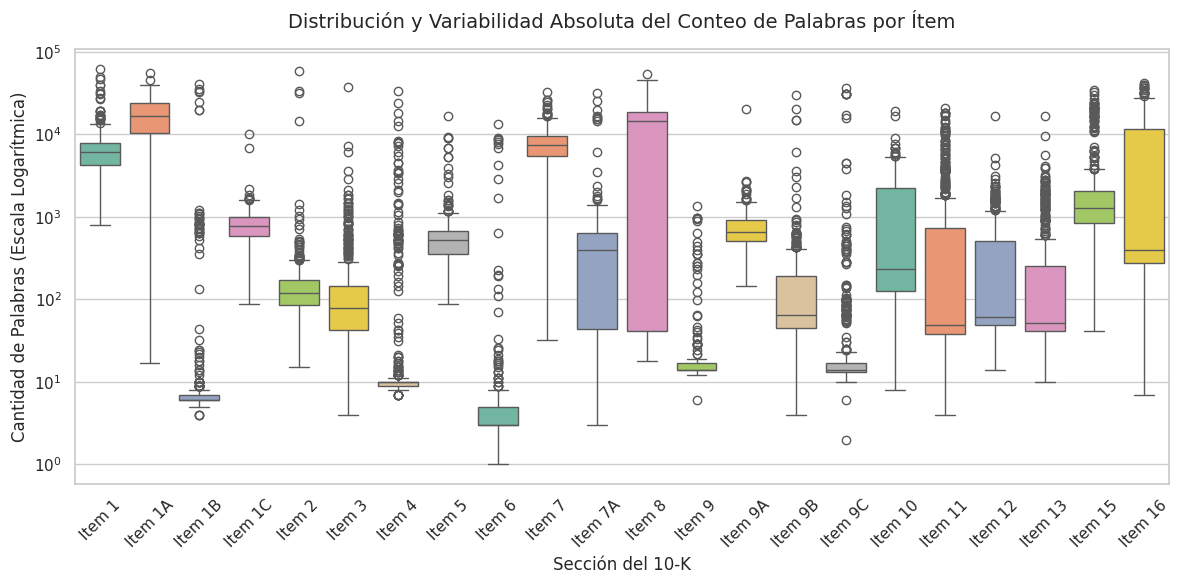

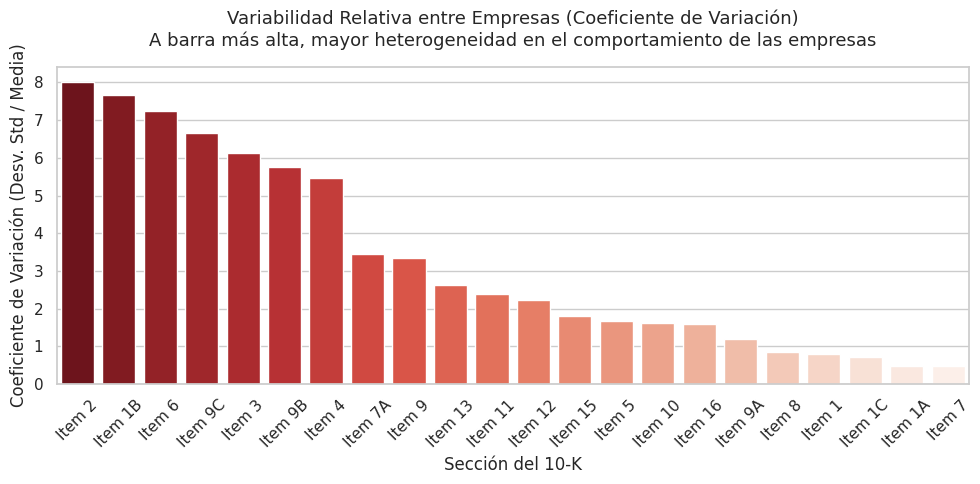

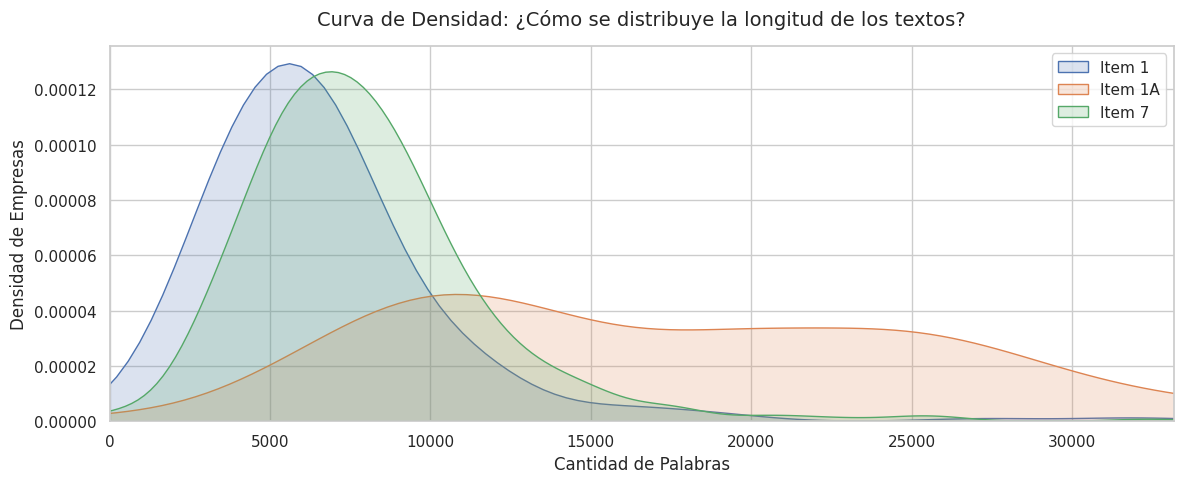

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREPARACIÓN DE DATOS Y MÉTRICAS
# ==========================================

# Identificar las columnas de los ítems (todas menos 'Ticker')
item_columns = [col for col in df_item_comparison.columns if col != 'Ticker']

# Clonamos el dataframe y reemplazamos los 0 por NaN para no adulterar la variabilidad
df_stats = df_item_comparison.copy()
df_stats[item_columns] = df_stats[item_columns].replace(0, np.nan)

# Calculamos los estadísticos básicos transpuestos (.T)
summary_table = df_stats[item_columns].describe().T

# Añadimos el Rango Intercuartílico (IQR) y el Coeficiente de Variación (CV)
summary_table['IQR'] = summary_table['75%'] - summary_table['25%']
summary_table['CV'] = summary_table['std'] / summary_table['mean']

# Renombramos columnas para mayor claridad en español
summary_table = summary_table.rename(columns={
    'mean': 'Media',
    '50%': 'Mediana',
    'std': 'Desv. Estándar',
    'min': 'Mínimo',
    'max': 'Máximo'
})

print("=== TABLA RESUMEN DE VARIABILIDAD POR ÍTEM ===")
display(summary_table[['Media', 'Mediana', 'Desv. Estándar', 'IQR', 'CV', 'Mínimo', 'Máximo']])


# ==========================================
# 2. VISUALIZACIÓN GRÁFICA
# ==========================================

# Configuración estética general
sns.set_theme(style="whitegrid")

# --- GRÁFICA A: Boxplot (Diagrama de Caja y Bigotes) ---
# Transformamos a formato "largo" (melt) requerido por Seaborn para comparar variables
df_long = df_stats.melt(id_vars=['Ticker'], value_vars=item_columns, var_name='Item', value_name='Palabras')
df_long = df_long.dropna() # eliminamos nulos para graficar

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_long, x='Item', y='Palabras', palette='Set2', hue='Item', legend=False)
plt.yscale('log') # CRÍTICO: Escala logarítmica para absorber diferencias de tamaño
plt.title('Distribución y Variabilidad Absoluta del Conteo de Palabras por Ítem', fontsize=14, pad=15)
plt.xlabel('Sección del 10-K', fontsize=12)
plt.ylabel('Cantidad de Palabras (Escala Logarítmica)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- GRÁFICA B: Gráfico de Barras del Coeficiente de Variación (CV) ---
# Ordenamos los ítems de mayor a menor variabilidad relativa
summary_sorted = summary_table.sort_values(by='CV', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=summary_sorted.index, y=summary_sorted['CV'], palette='Reds_r', hue=summary_sorted.index, legend=False)
plt.title('Variabilidad Relativa entre Empresas (Coeficiente de Variación)\nA barra más alta, mayor heterogeneidad en el comportamiento de las empresas', fontsize=13, pad=15)
plt.xlabel('Sección del 10-K', fontsize=12)
plt.ylabel('Coeficiente de Variación (Desv. Std / Media)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- GRÁFICA C: Histograma de Densidad (KDE) para Ítems Clave ---
# Elegimos 3 ítems icónicos para ver la "forma" de su variabilidad (puedes cambiarlos)
items_interes = [col for col in ['Item 1', 'Item 1A', 'Item 7'] if col in item_columns]

if items_interes:
    plt.figure(figsize=(12, 5))
    for item in items_interes:
        sns.kdeplot(df_stats[item], label=item, fill=True, alpha=0.2)
    plt.title('Curva de Densidad: ¿Cómo se distribuye la longitud de los textos?', fontsize=14, pad=15)
    plt.xlabel('Cantidad de Palabras', fontsize=12)
    plt.ylabel('Densidad de Empresas', fontsize=12)
    plt.xlim(0, df_stats[items_interes].quantile(0.95).max()) # Limitamos al percentil 95 para que los outliers no deformen la gráfica
    plt.legend()
    plt.tight_layout()
    plt.show()

---

### 3. ¿Cómo interpretar las gráficas?

1. **El Boxplot (Gráfica A):** Te mostrará los límites de longitud de cada sección. El tamaño de la "caja" representa el $IQR$. Si un ítem tiene una caja muy larga, significa que las empresas escriben extensiones muy distintas. Los puntos sueltos arriba y abajo son *outliers*: empresas hiper-extensas o reportes inusualmente breves.
2. **El Gráfico del Coeficiente de Variación (Gráfica B):** Es tu métrica estandarizada. Si el *Item 1A (Riesgos)* muestra un $CV$ de $0.60$ y el *Item 7 (MD&A)* muestra un $CV$ de $0.30$, significa que **el tamaño de los factores de riesgo es el doble de inestable/variable** entre empresas que el análisis financiero, sin importar cuál de las dos secciones sea más larga en promedio.
3. **La Curva de Densidad (Gráfica C):** Te enseñará la "silueta" de los datos. Verás si la variabilidad se distribuye de forma simétrica o si tiene una gran asimetría hacia la derecha (muchas empresas concentradas en textos cortos y unas pocas firmas gigantescas estirando el gráfico hacia palabras infinitas).

### Visualizing Word Counts by Key Item and Ticker

This grouped bar chart visually compares the word counts of 'Item 1' (Business), 'Item 1A' (Risk Factors), and 'Item 7' (MD&A) across the selected tech companies. It helps in understanding which companies provide more detailed disclosures in these critical sections.

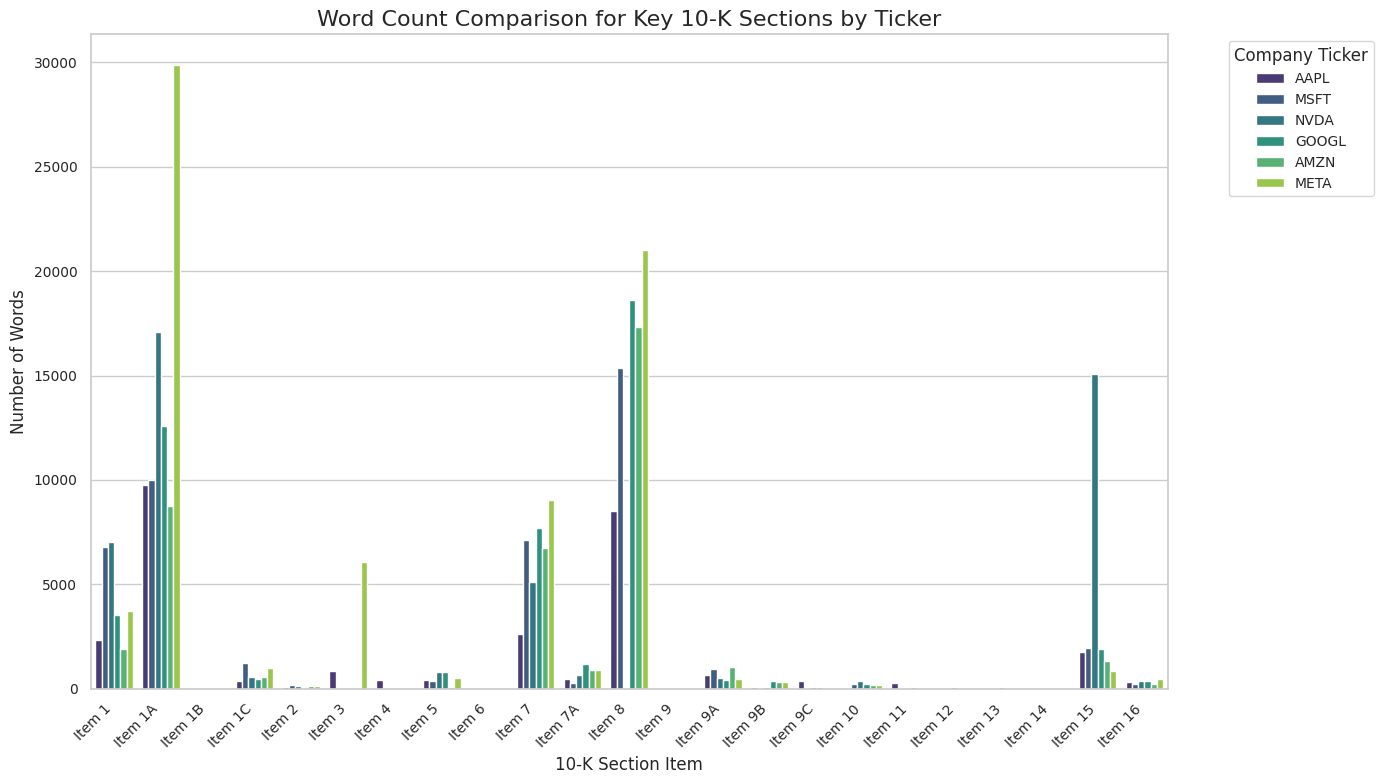

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted_plot = df_item_comparison.melt(
    id_vars=['Ticker'],
    value_vars=key_items_to_plot,
    var_name='Section Item',
    value_name='Word Count'
)

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create the grouped bar plot
sns.barplot(data=df_melted_plot, x='Section Item', y='Word Count', hue='Ticker', palette='viridis')

plt.title('Word Count Comparison for Key 10-K Sections by Ticker', fontsize=16)
plt.xlabel('10-K Section Item', fontsize=12)
plt.ylabel('Number of Words', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Company Ticker', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

To sort items like 'Item 1', 'Item 1A', 'Item 2', and 'Item 10' correctly (i.e., 'Item 1', 'Item 1A', 'Item 2', ..., 'Item 10'), a simple alphabetical sort isn't sufficient. Python's default `sort()` or `sorted()` would place 'Item 10' before 'Item 2' because it compares character by character. We need a custom sorting key that can extract the numerical part of the item and sort based on that, while also handling any trailing letters (like 'A' in 'Item 1A').

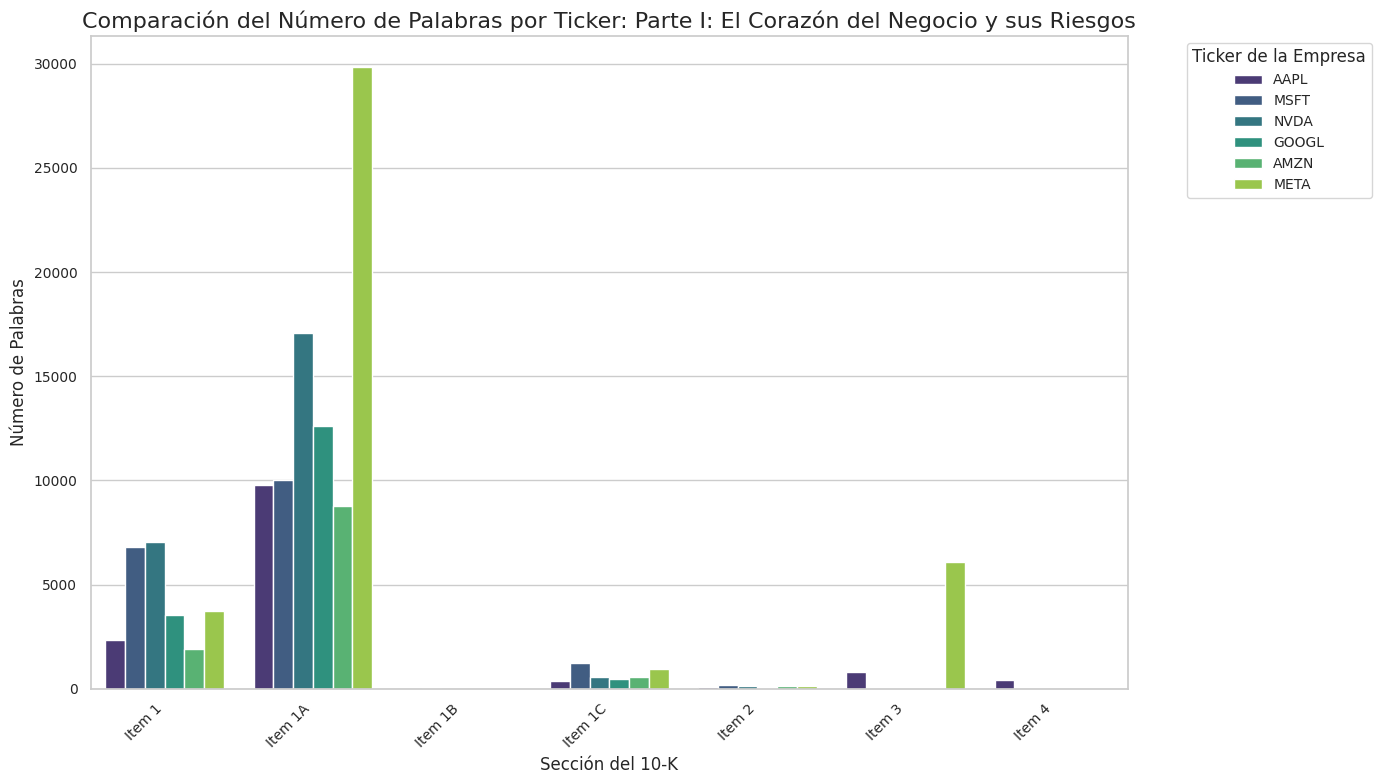

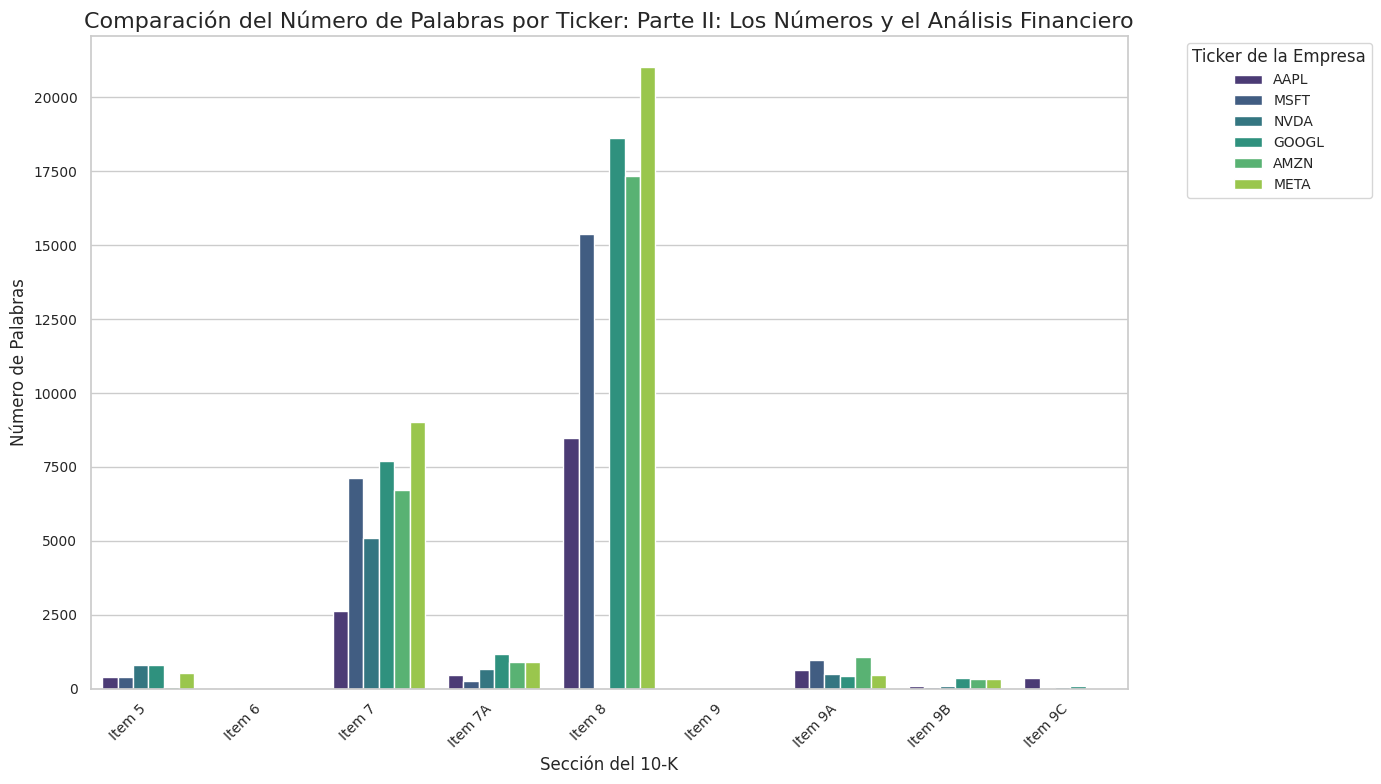

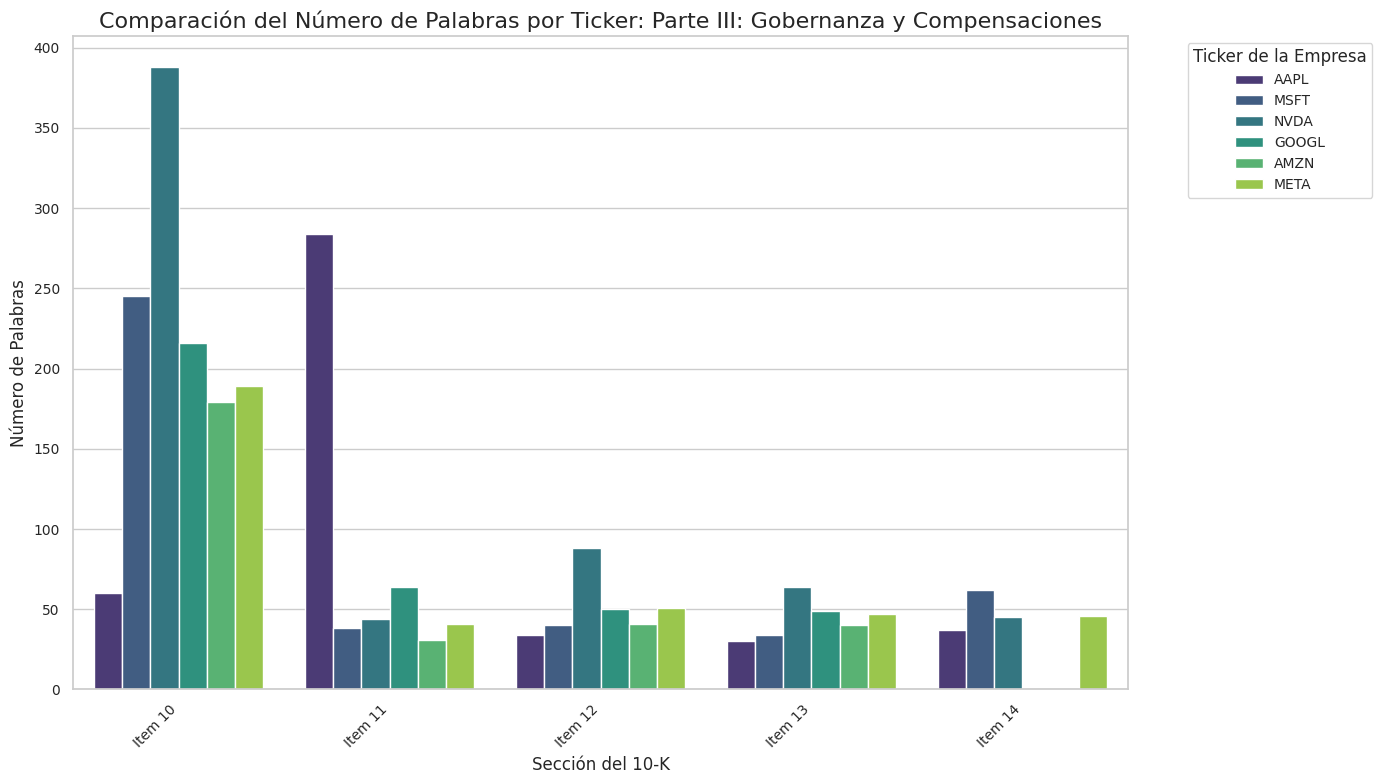

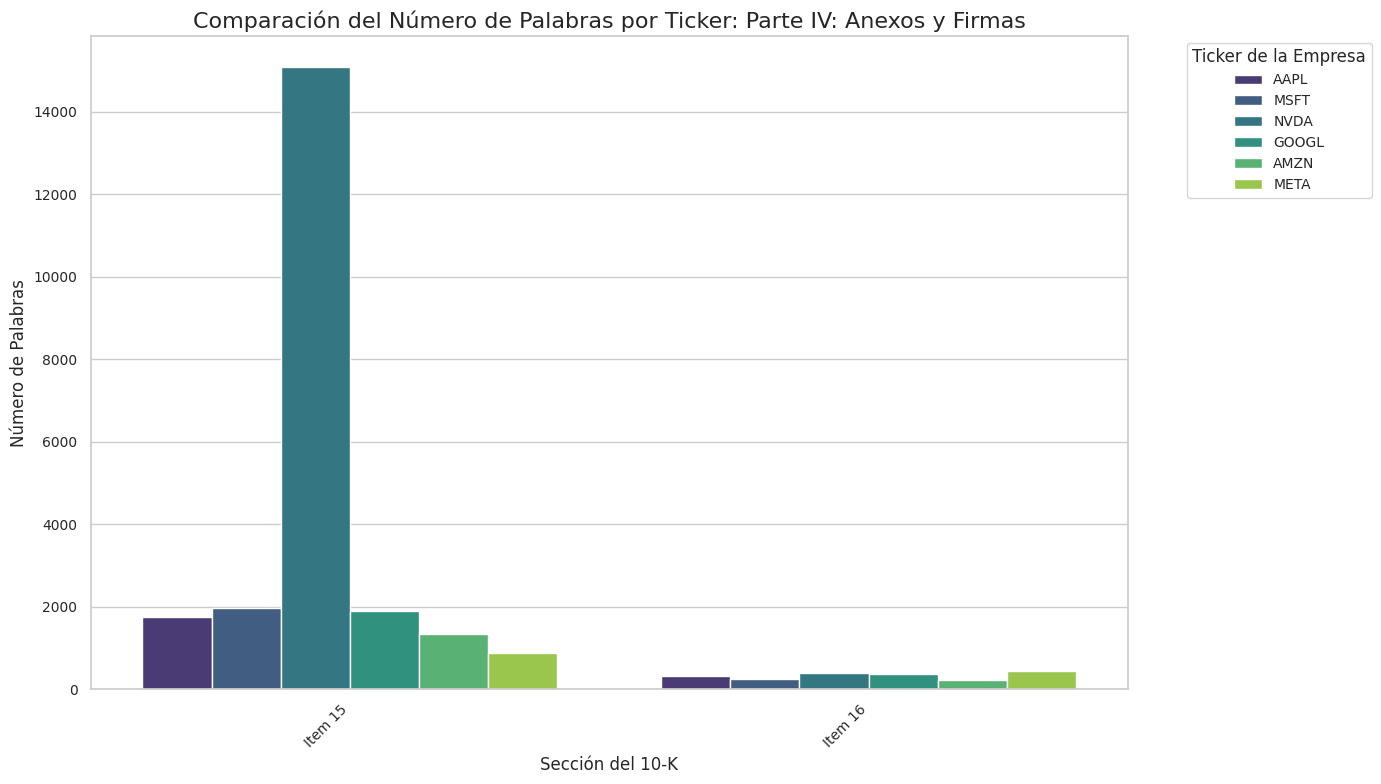

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df_item_comparison and key_items_to_plot are available from previous execution

# Define the items for each part of the 10-K based on the provided structure
parts_definition = {
    "Parte I: El Corazón del Negocio y sus Riesgos": [
        'Item 1', 'Item 1A', 'Item 1B', 'Item 1C', 'Item 2', 'Item 3', 'Item 4'
    ],
    "Parte II: Los Números y el Análisis Financiero": [
        'Item 5', 'Item 6', 'Item 7', 'Item 7A', 'Item 8', 'Item 9', 'Item 9A', 'Item 9B', 'Item 9C'
    ],
    "Parte III: Gobernanza y Compensaciones": [
        'Item 10', 'Item 11', 'Item 12', 'Item 13', 'Item 14'
    ],
    "Parte IV: Anexos y Firmas": [
        'Item 15', 'Item 16'
    ]
}

sns.set_theme(style="whitegrid")

for part_name, items_in_part in parts_definition.items():
    # Filter df_item_comparison for items relevant to the current part
    # Ensure that the items_in_part actually exist in the DataFrame columns
    valid_items_for_plot = [item for item in items_in_part if item in df_item_comparison.columns]

    if not valid_items_for_plot:
        print(f"No data available for {part_name}. Skipping plot.")
        continue

    # Select only the 'Ticker' column and the valid items for this part
    df_part = df_item_comparison[['Ticker'] + valid_items_for_plot]

    # Melt the DataFrame to long format for easier plotting with seaborn
    df_melted_part = df_part.melt(
        id_vars=['Ticker'],
        value_vars=valid_items_for_plot,
        var_name='Sección del 10-K',
        value_name='Número de Palabras'
    )

    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_melted_part, x='Sección del 10-K', y='Número de Palabras', hue='Ticker', palette='viridis')

    plt.title(f'Comparación del Número de Palabras por Ticker: {part_name}', fontsize=16)
    plt.xlabel('Sección del 10-K', fontsize=12)
    plt.ylabel('Número de Palabras', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Ticker de la Empresa', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.show()

## All Available Sections

A 10-K has over 20 sections. See what's available and how much text each contains:

In [27]:
for item in tenk.items:
    text = tenk[item]
    words = len(text.split())
    print(f"{item:12s} {words:>8,} words  {len(text):>8,} chars")
    print(text)

Item 9             16 words       117 chars
Table of Contents

Item 9.Changes in and Disagreements with Accountants on Accounting and Financial Disclosure

None.
Item 9A           468 words     3,197 chars
Item 9A.Controls and Procedures

Evaluation of Disclosure Controls and Procedures

Our management, with the participation of our chief executive officer (CEO) and chief financial officer (CFO), has evaluated the effectiveness of our disclosure controls and procedures (as defined in Rules 13a- 15(e) and 15d- 15(e) under the Securities Exchange Act of 1934, as amended (Exchange Act)), as of the end of the period covered by this Annual Report on Form 10-K. Based on such evaluation, our CEO and CFO have concluded that as of December 31, 2025, our disclosure controls and procedures are designed at a reasonable assurance level and are effective to provide reasonable assurance that information we are required to disclose in reports that we file or submit under the Exchange Act is recorded, 

## Search Within a Filing

Search for specific terms or topics within a filing to find relevant passages:

In [6]:
results = filing.search("artificial intelligence")
print(f"Found {len(results)} matching sections")
results

Found 2 matching sections


                                      Searching for 'artificial intelligence'                                      
  ╭──────────────────────────────────────────────────── 26 ─────────────────────────────────────────────────────╮  
  │ Item 1. Business Our Company NVIDIA pioneered accelerated computing to help solve the most challenging      │  
  │ computational problems. NVIDIA is now a data center scale AI infrastructure company reshaping all           │  
  │ industries. Our technology stack includes the foundational NVIDIA CUDA development platform that runs on    │  
  │ all NVIDIA GPUs, as well as hundreds of domain-specific software libraries, frameworks, algorithms,         │  
  │ software development kits, or SDKs, and application programming interfaces, or APIs. This deep and broad    │  
  │ software stack accelerates the performance and facilitates the deployment of NVIDIA accelerated computing   │  
  │ for computationally intensive workloads such as artificial intellige

## Structured Chunks for LLM Context

The chunked document breaks a filing into labeled segments, ideal for RAG pipelines or fitting within LLM context windows:

In [7]:
chunked = tenk.chunked_document
df = chunked.as_dataframe()

print(f"Total chunks: {len(df)}")
print(f"Columns: {df.columns.tolist()}\n")

# Chunks per section
sections = df[df["Item"] != ""].groupby("Item").agg(
    Chunks=("Chars", "count"),
    Total_Chars=("Chars", "sum")
).sort_values("Total_Chars", ascending=False)

sections.head(10)

Total chunks: 336
Columns: ['Text', 'Table', 'Chars', 'Signature', 'TocLink', 'Toc', 'Empty', 'Part', 'Item']



,Chunks,Total_Chars
Item,,
Item 15,197,160143
Item 1A,17,114427
Item 1,14,48199
Item 7,38,37713
Item 5,8,6742
Item 7A,2,4233
Item 1C,3,3946
Item 9A,2,3405
Item 10,1,2546


## Compare Text Volumes Across Companies

Different companies disclose varying levels of detail. Compare text volumes to understand disclosure depth:

In [8]:
tickers = ["NVDA", "MSFT", "AAPL", "GOOG"]
rows = []

for ticker in tickers:
    filing = Company(ticker).get_filings(form="10-K")[0]
    tenk = filing.obj()
    text = filing.text()
    rows.append({
        "Ticker": ticker,
        "Total Words": f"{len(text.split()):,}",
        "Business": f"{len(tenk['1'].split()):,}",
        "Risk Factors": f"{len(tenk['1A'].split()):,}",
        "MD&A": f"{len(tenk['7'].split()):,}",
    })

pd.DataFrame(rows).set_index("Ticker")

,Total Words,Business,Risk Factors,MD&A
Ticker,,,,
NVDA,"49,112","7,028","17,065","5,108"
MSFT,"45,954","6,806","10,020","7,131"
AAPL,"29,354","2,325","9,782","2,643"
GOOG,"49,582","3,551","12,591","7,703"


## Why EdgarTools?

EdgarTools is free and open-source. Compare extracting SEC filing text:

**With edgartools (free, no API key):**
```python
filing = Company("NVDA").get_filings(form="10-K")[0]
text = filing.text()            # Full text
tenk = filing.obj()
tenk["1A"]                      # Risk factors section
filing.search("AI")             # Search within filing
```

**Typical paid API approach ($50+/month, API key required):**
```python
from sec_api import ExtractorApi
api = ExtractorApi(api_key="YOUR_PAID_API_KEY")
text = api.get_section(url, "1A", "text")  # One section per API call
# ... rate-limited, paid per request, no search capability
```

With edgartools, the entire filing is parsed locally -- all sections, search, and chunks available instantly with no per-request cost.

## Quick Reference

```python
from edgar import *
set_identity("your.name@example.com")

# ── Full filing text ──
filing = Company("NVDA").get_filings(form="10-K")[0]
filing.text()                          # Plain text
filing.markdown()                      # Markdown
filing.html()                          # HTML

# ── Sections by item number ──
tenk = filing.obj()
tenk["1"]                              # Business description
tenk["1A"]                             # Risk factors
tenk["7"]                              # MD&A
tenk.items                             # List all items

# ── Search ──
filing.search("artificial intelligence")  # Find matching passages

# ── Structured chunks ──
chunked = tenk.chunked_document
df = chunked.as_dataframe()            # All chunks with metadata
# Columns: Text, Table, Chars, Part, Item
```

## What's Next

You've learned how to extract SEC filing text for NLP analysis. Here are related tutorials:

- [Analyze 10-K Annual Reports](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/analyze-10k-annual-report-python.ipynb)
- [Download SEC Filings in Bulk](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/download-sec-filings-bulk-python.ipynb)
- [Search and Filter SEC Filings](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/search-sec-filings-python.ipynb)
- [SEC EDGAR API in Python](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/sec-edgar-api-python.ipynb)

**Resources:**
- [EdgarTools Documentation](https://edgartools.readthedocs.io/)
- [GitHub Repository](https://github.com/dgunning/edgartools)
- [PyPI Package](https://pypi.org/project/edgartools/)

---

## Support EdgarTools

If you found this tutorial helpful, here are a few ways to support the project:

- **Star the repo** -- [github.com/dgunning/edgartools](https://github.com/dgunning/edgartools) -- it helps others discover edgartools
- **Visit edgartools.io** -- [edgartools.io](https://www.edgartools.io/) -- for more tutorials, articles, and updates
- **Report issues** -- found a bug or have a feature idea? [Open an issue](https://github.com/dgunning/edgartools/issues)
- **Share this notebook** -- know someone who works with SEC data? Send them the Colab link

*edgartools is free, open-source, and community-driven. No API key or paid subscription required.*